# ¿Cuál pronóstico es el mejor? El Conjunto de Confianza de Modelos

**Tienes cinco pronósticos de la tasa de desempleo. ¿Cuál es el mejor?**
El instinto es correr una carrera de pruebas por pares — Diebold-Mariano
(1995) para cada par — y coronar un ganador. Pero con $M$ modelos hay
$M(M-1)/2$ comparaciones, las pruebas se contradicen entre sí, y probarlas
todas al 10% garantiza falsos positivos. El ordenamiento sale
*intransitivo*: A empata con B, B empata con C, y sin embargo A le gana a C.
El **Conjunto de Confianza de Modelos** (Hansen, Lunde & Nason 2011,
*Econometrica*) lo resuelve. En vez de elegir un ganador devuelve un
*conjunto* — la colección más pequeña de modelos que contiene al mejor con
confianza $1-\alpha$ — *eliminando* iterativamente el peor modelo hasta que
los sobrevivientes son estadísticamente indistinguibles. Este notebook
construye una carrera pseudo-fuera-de-muestra real sobre datos laborales de
EE.UU. congelados, muestra que el DM por pares deja el ordenamiento
genuinamente ambiguo, y deja que el MCS
(`puremacro.forecast.model_confidence_set`) lo resuelva.

## El procedimiento en matemáticas

Sea $L_{i,t}$ la pérdida (aquí el error cuadrático de pronóstico) del
modelo $i$ en el momento $t$, y $d_{ij,t} = L_{i,t} - L_{j,t}$ el
diferencial de pérdida. La hipótesis nula de **igual capacidad predictiva**
sobre un conjunto $\mathcal{M}$ es
$$ H_{0,\mathcal M}:\quad \mathbb E[d_{ij,t}] = 0 \quad\text{para todo } i,j\in\mathcal M. $$
HLN estandarizan el diferencial promedio con un error estándar de bootstrap,
$t_{ij} = \bar d_{ij}/\widehat{\operatorname{sd}}(\bar d_{ij})$, y forman
un estadístico de equivalencia — el predeterminado es
$$ T_{\max,\mathcal M} = \max_{i\in\mathcal M} t_{i\cdot},\qquad
   t_{i\cdot} = \frac{\bar d_{i\cdot}}{\widehat{\operatorname{sd}}(\bar d_{i\cdot})}, $$
donde $\bar d_{i\cdot}$ es la pérdida media del modelo $i$ relativa al
promedio del conjunto (el rango $T_R$ y el semi-cuadrático $T_{SQ}$ son
alternativas). Un **bootstrap por bloques estacionario** (Politis-Romano
1994) que remuestrea bloques enteros de tiempo — compartidos entre modelos,
de modo que la dependencia serial *y* la dependencia entre modelos
sobreviven — da la distribución nula de $T$. Si se rechaza $H_0$, se elimina
el único peor modelo $e = \arg\max_i t_{i\cdot}$ y se repite. El **$p$-valor
MCS** de cada modelo es el máximo acumulado de los $p$-valores de la prueba
a lo largo de la ruta de eliminación, así que son monótonos: el conjunto
$\{i: p^{\text{MCS}}_i \ge \alpha\}$ se encoge al crecer $\alpha$.

**¿Por qué no simplemente el menor MSE?** Porque el error muestral hace que
el modelo de menor MSE a menudo no sea significativamente mejor que el
segundo lugar — declararlo "el mejor" exagera lo que respaldan los datos. ¿Y
por qué no DM por pares? Porque 15 pruebas por pares al 10% esperan ~1.5
rechazos falsos por construcción, y la imagen por pares puede ser
intransitiva. El MCS controla el error por familia de *toda* la comparación
y devuelve un conjunto honesto: "estos modelos están estadísticamente
empatados como mejores; el resto está vencido." Nota que el paquete incluye
una *segunda* función, no relacionada, con el mismo nombre —
`puremacro.nowcast.combine.model_confidence_set` — que es solo un sustituto
ligero por umbral usado para construir pesos de combinación (mantener los
modelos dentro de $(1+\alpha)$ del mejor MSE y promediarlos), sin bootstrap
ni control de tamaño. Este notebook usa el procedimiento de inferencia
genuino en `puremacro.forecast`.

## Preparación — una carrera fuera de muestra real

Pronosticamos la **tasa de desempleo de EE.UU.** un mes hacia adelante, de
forma recursiva: en cada fecha reestimamos cada modelo con datos hasta ese
punto y predecimos el siguiente valor — un ejercicio pseudo-fuera-de-muestra
genuino, sin mirar hacia adelante. La serie mensual desestacionalizada es el
panel congelado de JOLTS/BLS del notebook 18 (`beveridge18_us`, desde
2000-12). Limitamos la muestra a **antes de 2020** para que un solo dato
atípico de la pandemia no domine la pérdida cuadrática (una nota honesta de
robustez más abajo muestra que el MAE sobre la muestra completa separa los
modelos igual). Seis modelos en competencia:

- **RW** — caminata aleatoria (siguiente = último).
- **AR(1), AR(2), AR(4)** — autorregresiones, reestimadas por MCO cada paso.
- **MA(12)** — promedio móvil de 12 meses.
- **EWMA** — media ponderada exponencialmente (decaimiento 0.85).

In [1]:
import sys
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.forecast import (
    diebold_mariano, model_confidence_set, losses_from_forecasts,
)

us = load_csv("beveridge18_us")
us["date"] = pd.to_datetime(us["date"])
us = us[us["date"] < "2020-01-01"].reset_index(drop=True)   # pre-COVID
y = us["urate"].to_numpy(float)
dates = us["date"]
print(f"Tasa de desempleo de EE.UU.: {len(y)} meses "
      f"{dates.min().date()}..{dates.max().date()}")


def ar_forecast(hist: np.ndarray, p: int) -> float:
    """Pronóstico AR(p) a un paso por MCO sobre la historia (constante + p rezagos)."""
    if len(hist) < p + 5:
        return float(hist[-1])
    Y = hist[p:]
    X = np.column_stack([np.ones(len(hist) - p)]
                        + [hist[p - l:len(hist) - l] for l in range(1, p + 1)])
    b, *_ = np.linalg.lstsq(X, Y, rcond=None)
    x = np.array([1.0] + [hist[-l] for l in range(1, p + 1)])
    return float(x @ b)


MODELS = ["RW", "AR(1)", "AR(2)", "AR(4)", "MA(12)", "EWMA"]
START = 60  # empezar a pronosticar tras un rodaje de entrenamiento de 5 años
T = len(y)
F = np.full((T - START, len(MODELS)), np.nan)
for i, t in enumerate(range(START, T)):
    h = y[:t]
    F[i, 0] = h[-1]
    F[i, 1] = ar_forecast(h, 1)
    F[i, 2] = ar_forecast(h, 2)
    F[i, 3] = ar_forecast(h, 4)
    F[i, 4] = h[-12:].mean()
    w = 0.85 ** np.arange(len(h))[::-1]
    F[i, 5] = float((w * h).sum() / w.sum())

y_oos = y[START:T]
oos_dates = dates.iloc[START:T].reset_index(drop=True)
losses = losses_from_forecasts(F, y_oos, loss="mse")   # (T_oos, M)
rmse = np.sqrt(losses.mean(axis=0))
print(f"Ventana fuera de muestra: {oos_dates.iloc[0].date()}.."
      f"{oos_dates.iloc[-1].date()} (n={len(y_oos)})")
for m, r in sorted(zip(MODELS, rmse), key=lambda z: z[1]):
    print(f"  {m:6}  RMSE = {r:.3f} pp")

Tasa de desempleo de EE.UU.: 229 meses 2000-12-01..2019-12-01
Ventana fuera de muestra: 2005-12-01..2019-12-01 (n=169)
  AR(4)   RMSE = 0.165 pp
  RW      RMSE = 0.171 pp
  AR(2)   RMSE = 0.172 pp
  AR(1)   RMSE = 0.178 pp
  EWMA    RMSE = 0.625 pp
  MA(12)  RMSE = 0.667 pp


## Paso 1 — el Diebold-Mariano por pares deja el ordenamiento ambiguo

El modelo de menor RMSE parece un ganador, pero ¿es *significativamente* el
mejor? El mapa de calor abajo muestra el $p$-valor DM de cada par (oscuro =
el par es estadísticamente distinguible al 10%). Léelo y la ambigüedad salta
a la vista.

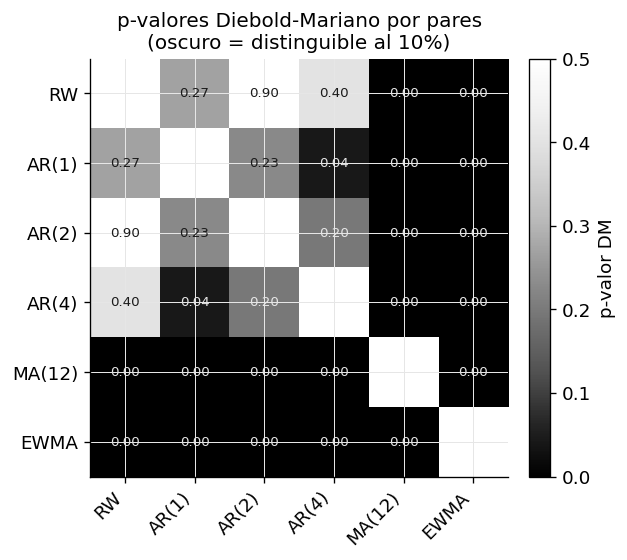

10 de 15 pruebas por pares rechazan igual precisión al 10%.
  RW vs AR(2):   p=0.898  (indistinguibles)
  AR(1) vs AR(4):p=0.042  (AR(4) 'significativamente' mejor)
  RW vs AR(1):   p=0.270  (indistinguibles)
=> AR(4) le gana a AR(1), pero ninguno le gana a RW, y RW empata con AR(2): el ordenamiento por pares es intransitivo.


In [2]:
M = len(MODELS)
Pdm = np.full((M, M), np.nan)
for a, b in itertools.combinations(range(M), 2):
    p = diebold_mariano(F[:, a] - y_oos, F[:, b] - y_oos, h=1, loss="mse")["p_value"]
    Pdm[a, b] = Pdm[b, a] = p

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(Pdm, cmap="Greys_r", vmin=0.0, vmax=0.5)
ax.set_xticks(range(M)); ax.set_xticklabels(MODELS, rotation=45, ha="right")
ax.set_yticks(range(M)); ax.set_yticklabels(MODELS)
for a in range(M):
    for b in range(M):
        if a != b:
            ax.text(b, a, f"{Pdm[a, b]:.2f}", ha="center", va="center",
                    fontsize=8, color="0.9" if Pdm[a, b] < 0.2 else "0.1")
ax.set_title("p-valores Diebold-Mariano por pares\n(oscuro = distinguible al 10%)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="p-valor DM")
plt.tight_layout(); plt.show()

# La intransitividad, explícita:
n_sig = int(np.nansum(Pdm[np.triu_indices(M, 1)] < 0.10))
print(f"{n_sig} de {M*(M-1)//2} pruebas por pares rechazan igual precisión al 10%.")
print(f"  RW vs AR(2):   p={Pdm[0,2]:.3f}  (indistinguibles)")
print(f"  AR(1) vs AR(4):p={Pdm[1,3]:.3f}  (AR(4) 'significativamente' mejor)")
print(f"  RW vs AR(1):   p={Pdm[0,1]:.3f}  (indistinguibles)")
print("=> AR(4) le gana a AR(1), pero ninguno le gana a RW, y RW empata con "
      "AR(2): el ordenamiento por pares es intransitivo.")

**Leyendo el mapa de calor.** Los dos suavizadores (MA(12), EWMA) están
oscuros contra todos — claramente vencidos, porque van rezagados en los
puntos de giro. Pero dentro de la familia AR las celdas están claras ($p$
grande): la mayoría de los pares son indistinguibles. La única excepción,
AR(1) vs AR(4) en $p\approx0.04$, es justo el tipo de celda "significativa"
solitaria que esperas que aparezca por azar cuando corres quince pruebas al
10% — y fabrica una contradicción, porque AR(4) supuestamente le gana a
AR(1) mientras ambos empatan con la caminata aleatoria. Las pruebas por
pares no pueden dar una respuesta coherente a "¿cuál modelo es el mejor?".

## Paso 2 — el Conjunto de Confianza de Modelos lo resuelve

Ahora entrega la misma matriz de pérdidas al MCS. Hace bootstrap de la nula
conjunta, elimina el peor modelo, y repite — reportando un solo conjunto
coherente.

In [3]:
res = model_confidence_set(losses, alpha=0.10, statistic="tmax",
                           n_boot=5000, block=None, seed=20260724)
kept = [MODELS[i] for i in res["included"]]
dropped = [MODELS[i] for i in res["excluded"]]
print(f"MCS al 90% de confianza (alpha=0.10, T_max, bootstrap estacionario):")
print(f"  RETENIDOS : {kept}")
print(f"  ELIMINADOS: {dropped}")
print(f"  orden de eliminación (peor primero): "
      f"{[MODELS[i] for i in res['elimination_order']]}")
print("  p-valores MCS:")
for i in np.argsort(-res["pvalues"]):
    tag = "  <- en el conjunto" if res["pvalues"][i] >= 0.10 else ""
    print(f"    {MODELS[i]:6}  p_MCS = {res['pvalues'][i]:.3f}{tag}")

MCS al 90% de confianza (alpha=0.10, T_max, bootstrap estacionario):
  RETENIDOS : ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  ELIMINADOS: ['MA(12)', 'EWMA']
  orden de eliminación (peor primero): ['EWMA', 'MA(12)', 'AR(1)', 'AR(2)', 'RW']
  p-valores MCS:
    AR(4)   p_MCS = 1.000  <- en el conjunto
    RW      p_MCS = 0.668  <- en el conjunto
    AR(2)   p_MCS = 0.491  <- en el conjunto
    AR(1)   p_MCS = 0.126  <- en el conjunto
    MA(12)  p_MCS = 0.034
    EWMA    p_MCS = 0.026


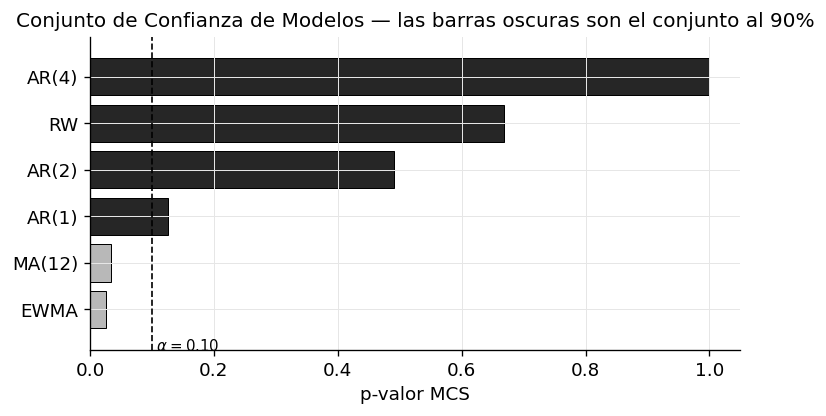

In [4]:
order = np.argsort(res["pvalues"])
fig, ax = plt.subplots(figsize=(6.4, 3.6))
cols = ["0.15" if res["pvalues"][i] >= 0.10 else "0.72" for i in order]
ax.barh([MODELS[i] for i in order], res["pvalues"][order], color=cols,
        edgecolor="0.0", linewidth=0.6)
ax.axvline(0.10, color="0.0", lw=1.0, ls="--")
ax.text(0.10, -0.6, r" $\alpha=0.10$", fontsize=9, va="top")
ax.set_xlabel("p-valor MCS")
ax.set_title("Conjunto de Confianza de Modelos — las barras oscuras son el conjunto al 90%")
ax.margins(y=0.08)
plt.tight_layout(); plt.show()

**La resolución.** El MCS mantiene los cuatro modelos de la familia AR
{RW, AR(1), AR(2), AR(4)} y elimina los dos suavizadores — un veredicto
limpio y coherente donde las pruebas por pares se contradecían. La lectura
es honesta: al horizonte mensual la tasa de desempleo se parece a una
caminata aleatoria, así que una autorregresión de orden bajo bien
especificada no puede distinguirse de ella fuera de muestra, mientras que
los promedios rezagados que responden con lentitud a los puntos de giro son
decisivamente peores. El MCS *no* pretende coronar a un único ganador que no
puede defender estadísticamente.

## Robustez — la elección del estadístico y la muestra COVID

Dos chequeos rápidos de honestidad. Primero, los estadísticos de rango $T_R$
y semi-cuadrático $T_{SQ}$ dan el mismo conjunto que $T_{\max}$. Segundo, si
volvemos a meter los meses del COVID y cambiamos a la pérdida MAE robusta a
atípicos (para que un solo pico de 10 puntos no domine), sobreviven los
mismos cuatro.

In [5]:
for stat in ("tmax", "tr", "tsq"):
    r = model_confidence_set(losses, alpha=0.10, statistic=stat,
                             n_boot=5000, seed=20260724)
    print(f"  {stat:5}: {[MODELS[i] for i in r['included']]}")

# Muestra completa (incl. COVID), pérdida MAE robusta.
full = load_csv("beveridge18_us"); full["date"] = pd.to_datetime(full["date"])
yf = full["urate"].to_numpy(float); Tf = len(yf)
Ff = np.full((Tf - START, len(MODELS)), np.nan)
for i, t in enumerate(range(START, Tf)):
    h = yf[:t]
    Ff[i, 0] = h[-1]; Ff[i, 1] = ar_forecast(h, 1)
    Ff[i, 2] = ar_forecast(h, 2); Ff[i, 3] = ar_forecast(h, 4)
    Ff[i, 4] = h[-12:].mean()
    w = 0.85 ** np.arange(len(h))[::-1]; Ff[i, 5] = float((w * h).sum() / w.sum())
Lf = losses_from_forecasts(Ff, yf[START:Tf], loss="mae")
rf = model_confidence_set(Lf, alpha=0.10, statistic="tmax", n_boot=5000, seed=20260724)
print(f"  muestra completa, pérdida MAE: {[MODELS[i] for i in rf['included']]}")

  tmax : ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  tr   : ['RW', 'AR(1)', 'AR(2)', 'AR(4)', 'MA(12)']
  tsq  : ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  muestra completa, pérdida MAE: ['RW', 'AR(1)', 'AR(2)', 'AR(4)']


## Tu turno — aprieta la confianza, cambia el objetivo

El nivel de confianza es una perilla. Sube $\alpha$ (menor confianza) y el
conjunto debe (débilmente) encogerse hacia el único mejor modelo; bájalo y
el conjunto crece. Traza todo el anidamiento abajo, luego prueba
pronosticar otra serie (la tasa de vacantes `v_rate`, o `quits_rate`).

  alpha=0.02 (conf 98%): ['RW', 'AR(1)', 'AR(2)', 'AR(4)', 'MA(12)', 'EWMA']
  alpha=0.05 (conf 95%): ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  alpha=0.10 (conf 90%): ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  alpha=0.25 (conf 75%): ['RW', 'AR(2)', 'AR(4)']
  alpha=0.50 (conf 50%): ['RW', 'AR(4)']


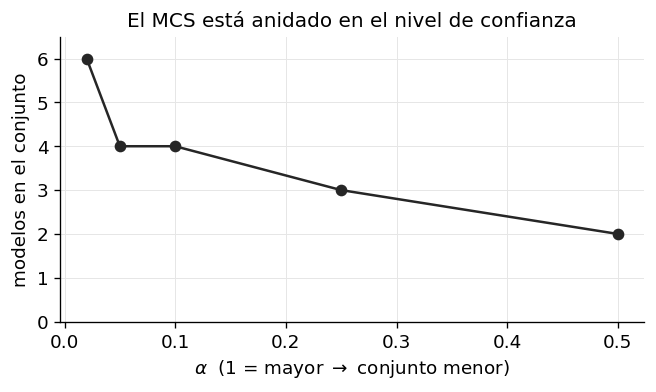

In [6]:
# <- Cambia esto:
ALPHA_GRID = [0.02, 0.05, 0.10, 0.25, 0.50]

sizes = []
for a in ALPHA_GRID:
    r = model_confidence_set(losses, alpha=a, statistic="tmax",
                             n_boot=5000, seed=20260724)
    sizes.append(len(r["included"]))
    print(f"  alpha={a:.2f} (conf {1-a:.0%}): "
          f"{[MODELS[i] for i in r['included']]}")
assert all(sizes[i] >= sizes[i + 1] for i in range(len(sizes) - 1)), \
    "el MCS debe estar anidado: mayor alpha => conjunto (débilmente) menor"

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(ALPHA_GRID, sizes, "-o", color="0.15")
ax.set_xlabel(r"$\alpha$  (1 = mayor $\to$ conjunto menor)")
ax.set_ylabel("modelos en el conjunto")
ax.set_title("El MCS está anidado en el nivel de confianza")
ax.set_ylim(0, len(MODELS) + 0.5)
plt.tight_layout(); plt.show()

**Ejercicios.** (1) *Básico*: cambia el objetivo a `v_rate` (tasa de
vacantes) y reconstruye la carrera — ¿sobrevive la misma separación
AR-vs-suavizador, o la serie más persistente deja que el MCS corone menos
modelos? (2) *Intermedio*: agrega dos competidores más (una tendencia
lineal, un AR(12)) para que la familia tenga ocho modelos; con $M=8$ hay 28
pruebas DM por pares — cuenta cuántas "rechazan" falsamente al 10% antes de
que el MCS las limpie. (3) *Avanzado*: reemplaza el bootstrap estacionario
por el esquema de bloques móviles (`bootstrap="moving"`) y varía `block` de
3 a 24; el conjunto retenido es una elección de especificación, y su
estabilidad a lo largo de las longitudes de bloque es en sí misma el chequeo
de robustez que recomiendan HLN.

**¿Qué tan completo es esto?** `puremacro.forecast.model_confidence_set`
acepta ya sea una matriz de pérdidas lista o `forecasts` + `realized` (vía
`losses_from_forecasts`, con pérdidas `mse`/`mae`/`lp`), los tres
estadísticos (`tmax`/`tr`/`tsq`), ambos esquemas de bloques, y una semilla
para reproducibilidad exacta. Se compone con `forecast.diebold_mariano` /
`giacomini_white` para la vista por pares, con `forecast.density`
(CRPS/PIT/KLIC) cuando las pérdidas son puntajes de *densidad* en vez de
errores puntuales, y con los pesos de combinación de
`puremacro.nowcast.combine` — cuyo ayudante homónimo por umbral es el primo
ligero de la prueba de eliminación genuina que se usa aquí.